# Import the libraries

In [1]:
# Import the libraries that you need
from pathlib import Path

import medigan
import torch
import torchvision
from torchvision.io import read_image
from torchvision.utils import make_grid
from tqdm.notebook import tqdm



# The availability of GPUs

In [10]:
if torch.cuda.is_available():
    device= "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"we are using {device}")

we are using mps


# Find a GAN in Medigan

In [12]:
# Create the connection to the Medigan generators
generators = medigan.Generators()

# Find the models that match what we want
values = ["mammogram", "roi"]
models = generators.find_matching_models_by_values(values)
model_id = models[0].model_id

print(model_id)


00004_PIX2PIX_MMG_MASSES_W_MASKS


# Get the model config

In [16]:
model_config = generators.get_config_by_id(model_id)

print(f"Model keys: {model_config.keys()}")

Model keys: dict_keys(['execution', 'selection', 'description'])


# Select predefined keys from the model

In [21]:

model_info = {
  k: model_config["selection"][k] for k in ["generates","tags","height","width"]
}

model_info

{'generates': ['regions of interest',
  'ROI',
  'mammograms',
  'patches',
  'full-field digital mammograms'],
 'tags': ['Mammogram',
  'Mammography',
  'Digital Mammography',
  'Full field Mammography',
  'Full-field Mammography',
  'pix2pix',
  'Pix2Pix',
  'Mass segmentation',
  'Breast lesion'],
 'height': 256,
 'width': 256}

# Create a output directory

In [24]:
output_dir = Path("output")
sample_dir = output_dir / "sample_mammogram"

# Create the directory with mkdir
sample_dir.mkdir(parents=True, exist_ok=True)

print(sample_dir)


output/sample_mammogram


# Generate 4 images of mammogram

In [31]:
generators.generate(model_id=model_id,num_samples=4,output_path=sample_dir,install_dependencies=True )

100%|█████████████████████████████████████████████| 1/1 [00:04<00:00,  4.86s/it]


# Lets view images

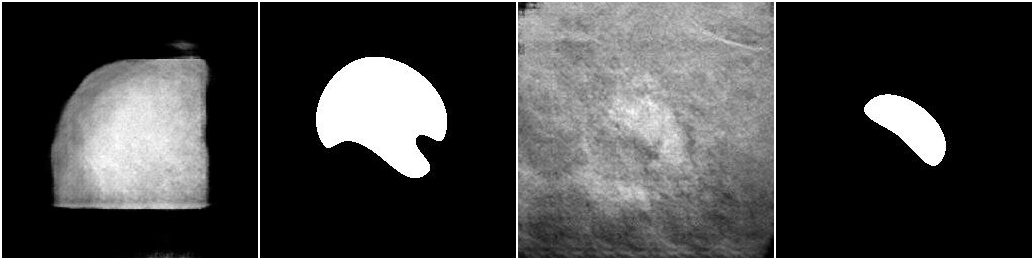

In [36]:
def view_images(directory, num_images=4, glob_rule="*.jpg"):
    """Displays a sample of images in the given directory
    They'll display in rows of 4 images
    - directory: which directory to look for images
    - num_images: how many images to display (default 4, for one row)
    - glob_rule: argument to glob to filter images (default "*" selects all)"""

    image_list = list(directory.glob(glob_rule))  # REMOVERHS
    num_samples = min(num_images, len(image_list))
    images = [read_image(str(f)) for f in sorted(image_list)[:num_samples]]  # REMOVERHS
    grid = make_grid(images, nrow=4, pad_value=255.0)
    return torchvision.transforms.ToPILImage()(grid)


sample_images = view_images(sample_dir)
sample_images

# Generate the training data

In [39]:
train_dataloader = generators.get_as_torch_dataloader(
    model_id=model_id, num_samples=50, batch_size=4, shuffle=True, prefetch_factor=None
)

sample_batch = next(iter(train_dataloader))
print(f"Training data loader with keys: {sample_batch.keys()}")


Training data loader with keys: dict_keys(['sample', 'mask'])


# Create a data loader of validation data

In [42]:
val_dataloader = generators.get_as_torch_dataloader(
    model_id=model_id, num_samples=30, batch_size=4, shuffle=False, prefetch_factor=None
)

val_batch = next(iter(train_dataloader))
shape = val_batch["sample"].shape
dtype = val_batch["sample"].dtype
print(f"Validation image with data shape {shape} and type {dtype}")


Validation image with data shape torch.Size([4, 256, 256]) and type torch.float32


# Get the shape and type for the mask

In [45]:
shape = val_batch["mask"].shape
dtype = val_batch["mask"].dtype

print(f"Validation mask with data shape {shape} and type {dtype}")


Validation mask with data shape torch.Size([4, 256, 256]) and type torch.uint8


We'll need to fix this, we need the images to be [3, 256, 256] and the mask to be [1, 256, 256], and both to have type float32

# Make function converts the type and adds the channels.

In [49]:
def convert_to_torch_image(tensor, color=False):
    tensor_float = tensor.type(torch.float32)
    grayscale = tensor_float.unsqueeze(1)
    if color:
        return grayscale.repeat(1, 3, 1, 1)
    else:
        return grayscale

In [51]:
mask_converted = convert_to_torch_image(val_batch["mask"])

shape = mask_converted.shape
dtype = mask_converted.dtype

print(f"Validation mask with data shape {shape} and type {dtype}")

Validation mask with data shape torch.Size([4, 1, 256, 256]) and type torch.float32


In [53]:
sample_converted = convert_to_torch_image(val_batch["sample"],color=True)


shape = sample_converted.shape
dtype = sample_converted.dtype

print(f"Validation mask with data shape {shape} and type {dtype}")

Validation mask with data shape torch.Size([4, 3, 256, 256]) and type torch.float32


# Load the pre-trained deeplabv3_resnet50 model

In [58]:
pretrained_weights = (
    torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
)

model = torchvision.models.segmentation.deeplabv3_resnet50(weights=pretrained_weights)

print("Model components:")
for name, part in model.named_children():
    print("\t" + name)


Model components:
	backbone
	classifier
	aux_classifier


This model gives a dictionary with two outputs: out and aux. We only want out

# Lets run the model on the sample part of our sample_batch

In [62]:
sample_converted = convert_to_torch_image(sample_batch["sample"], True)
model_result = model(sample_converted)
model_out = model_result["out"]
out_shape = model_out.shape

out_shape


torch.Size([4, 21, 256, 256])

This doesn't match our masks

# Lets change the last layer in the classifier

In [66]:
new_final_layer = torch.nn.Conv2d(256, 1, kernel_size=(1, 1))
model.classifier[-1] = new_final_layer

new_out = model(sample_converted)["out"]
print(f"New model output shape: {new_out.shape}")
print(f"Mask shape: {mask_converted.shape}")


New model output shape: torch.Size([4, 1, 256, 256])
Mask shape: torch.Size([4, 1, 256, 256])


# Create loss function and optimizer

In [69]:
loss_fun = torch.nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(params=model.parameters())


# Make a function for calculating the loss

In [77]:
def compute_loss(batch, model, loss_fun):
    # Extract the sample and mask from the batch
    sample = batch["sample"]
    mask = batch["mask"]

    # Convert the sample and mask to the correct shape and type
    sample_correct = convert_to_torch_image(sample, color=True)
    mask_correct = convert_to_torch_image(mask)

    # move the sample and mask to the GPU
    sample_gpu = sample_correct.to(device)
    mask_gpu = mask_correct.to(device)

    # Run the model on the sample and select the classifier (out key)
    output = model(sample_gpu)["out"]

    # Compute the loss
    loss = loss_fun(output, mask_gpu)

    return loss


In [79]:
model.to(device)

compute_loss(sample_batch, model, loss_fun)

tensor(0.6682, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

#  Trains model for one epoch on training data and validates on validation data, returning average training and validation losses.

In [85]:
def train_epoch(model, train_dataloader, val_dataloader, loss_fun, opt):
    model.train()

    # Training part
    train_loss = 0.0
    train_count = 0
    for batch in tqdm(train_dataloader):
        # zero the gradients on the optimizer
        opt.zero_grad()

        # compute the loss for the batch
        loss = compute_loss(batch, model, loss_fun)

        # Compute the backward part of the loss and step the optimizer
        loss.backward()
        opt.step()

        train_loss += loss.item()
        train_count += 1

    # Validation part
    val_loss = 0.0
    val_count = 0
    for batch in tqdm(val_dataloader):
        # compute the loss for each batch
        loss = compute_loss(batch, model, loss_fun)

        val_loss += loss.item()
        val_count += 1

    return train_loss / train_count, val_loss / val_count


In [88]:
train_epoch(model, train_dataloader, val_dataloader, loss_fun, opt)

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

(0.38132287103396195, 0.25349574349820614)

We get two losses

# Make a function for 9 epoch

In [118]:
def train_9_epochs(model, train_dataloader, val_dataloader, loss_fun, opt):
    train_losses = []
    val_losses = []
    
    for epoch in range(9):
        train_loss, val_loss = train_epoch(model, train_dataloader, val_dataloader, loss_fun, opt)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/9 - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    return train_losses, val_losses

In [120]:
train_9_epochs(model, train_dataloader, val_dataloader, loss_fun, opt)

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/9 - Train Loss: 0.1835, Val Loss: 0.1844


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch 8/9 - Train Loss: 0.0666, Val Loss: 0.1225


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Epoch 9/9 - Train Loss: 0.0653, Val Loss: 0.1481


([0.18351664795325354,
  0.12467043617596993,
  0.09932162669988778,
  0.08885137908733808,
  0.08252439590600821,
  0.0704139473919685,
  0.06692593344129048,
  0.066552417496076,
  0.06525643227192071],
 [0.18435960449278355,
  0.13622095622122288,
  0.12768546026200056,
  0.1549270860850811,
  0.11353694833815098,
  0.1345580881461501,
  0.1301501113921404,
  0.12245947495102882,
  0.14808995928615332])

# Load the pretrained model

In [96]:
model = torch.load('models/00001_DCGAN_MMG_CALC_ROI/00001_DCGAN_MMG_CALC_ROI/DCGAN.pt').to(device)

AttributeError: 'dict' object has no attribute 'to'

# Create a dataloader for test data

In [123]:
test_dataloader = generators.get_as_torch_dataloader(
    model_id=model_id,num_samples=8,batch_size=4,shuffle=False,prefetch_factor=None
)

test_batch = next(iter(test_dataloader))

print(f"Data loader images in batches of {test_batch['sample'].size(0)}")

Data loader images in batches of 4


# Run the model on the test_batch

In [125]:
corrected_sample = convert_to_torch_image(test_batch["sample"], color=True)
corrected_sample = corrected_sample.to(device)

test_result = model(corrected_sample)["out"]

test_result.shape


torch.Size([4, 1, 256, 256])

# Apply the sigmoid function to the test_result

In [127]:
test_mask_model = torch.sigmoid(test_result)

# Lets plot our results

In [130]:
def plot_images_from_tensor(tensor):
    grid = make_grid(tensor, nrow=4, pad_value=1.0)
    return torchvision.transforms.ToPILImage()(grid)

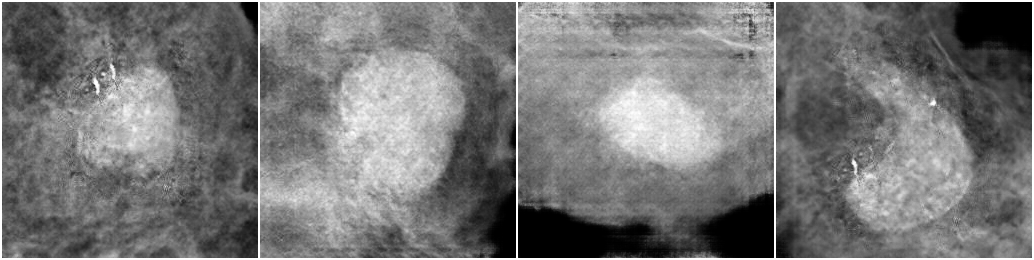

In [132]:
# Plot the sample part of the test_batch
sample_test_batch_plot = plot_images_from_tensor(convert_to_torch_image(test_batch["sample"]))
sample_test_batch_plot


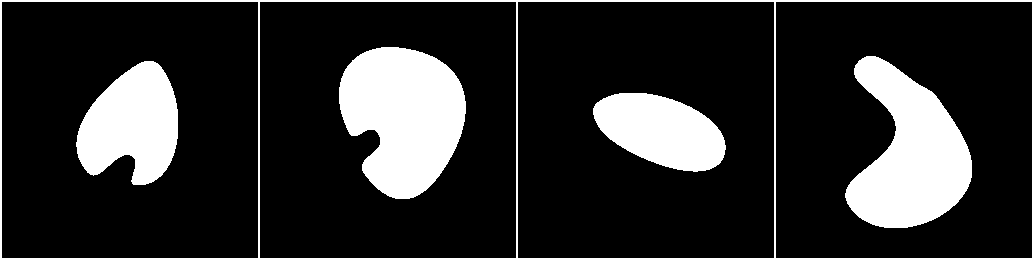

In [134]:
# Plot the mask part of the test_batch
mask_test_batch_plot = plot_images_from_tensor(convert_to_torch_image(test_batch["mask"]))
mask_test_batch_plot

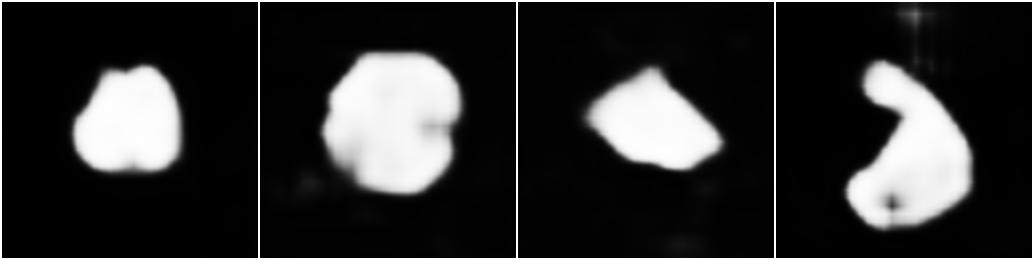

In [136]:
# Plot the result of the model running
model_result_plot = plot_images_from_tensor(test_mask_model)
model_result_plot